In [2]:
import os
import sys
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from scipy import signal as sn 
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json

BDC is using numpy


In [ ]:
#define some basic functions here, like xcorr and etc

@nb.njit()
def get_common_rows(specnum0,specnum1,idxstart0,idxstart1):
    nrows0,nrows1=specnum0.shape[0],specnum1.shape[0]
    maxrows=min(nrows0,nrows1)
    rownums0=np.empty(maxrows,dtype='int64')
    rownums0[:]=-1
    rownums1=rownums0.copy()
    rowidx=rownums0.copy()
    i=0;j=0;row_count=0;
    while i<nrows0 and j<nrows1:
        if (specnum0[i]-idxstart0)==(specnum1[j]-idxstart1):
            rownums0[row_count]=i
            rownums1[row_count]=j
            rowidx[row_count]=specnum0[i]-idxstart0
            i+=1
            j+=1
            row_count+=1
        elif (specnum0[i]-idxstart0)>(specnum1[j]-idxstart1):
            j+=1
        else:
            i+=1
    return row_count,rownums0,rownums1,rowidx

@nb.njit(parallel=True)
def avg_xcorr_4bit_2ant_float(pol0,pol1,specnum0,specnum1,idxstart0,idxstart1,delay=None,freqs=None):
    row_count,rownums0,rownums1,rowidx=get_common_rows(specnum0,specnum1,idxstart0,idxstart1)
    ncols=pol0.shape[1]
#     print("ncols",ncols)
    assert pol0.shape[1]==pol1.shape[1]
    xcorr=np.zeros((row_count,ncols),dtype='complex64') # in the dev_gen_phases branch
    if delay is not None:
        for i in nb.prange(row_count):
            for j in range(ncols):
                xcorr[i,j] = pol0[rownums0[i],j]*np.conj(pol1[rownums1[i],j]*np.exp(2j*np.pi*delay[rowidx[i]]*freqs[j]))
    else:
        for i in nb.prange(row_count):
            xcorr[i,:] = pol0[rownums0[i],:]*np.conj(pol1[rownums1[i],:])
    return xcorr

def get_coarse_xcorr(f1, f2, Npfb=4096):
    if len(f1.shape) == 1:
        f1 = f1.reshape(-1, 1)
    if len(f2.shape) == 1:
        f2 = f2.reshape(-1, 1)
    chans = f1.shape[1]
    Nsmall = f1.shape[0]
    wt = np.zeros(2 * Nsmall)
    wt[:Nsmall] = 1
    n_avg = np.fft.irfft(np.fft.rfft(wt) * np.conj(np.fft.rfft(wt)))
#     print(n_avg)
#     n_avg[Nsmall] = np.nan
#     print(n_avg[Nsmall-10:Nsmall+10])
    n_avg = np.tile(n_avg, chans).reshape(chans, 2*Nsmall)
#     print(n_avg.shape)
    bigf1 = np.vstack([f1, np.zeros(f1.shape, dtype=f1.dtype)])
    bigf2 = np.vstack([f2, np.zeros(f2.shape, dtype=f2.dtype)])
    bigf1 = bigf1.T.copy()
    bigf2 = bigf2.T.copy()
    bigf1f = np.fft.fft(bigf1,axis=1)
    bigf2f = np.fft.fft(bigf2,axis=1)
    xx = bigf1f * np.conj(bigf2f)
    xcorr = np.fft.ifft(xx,axis=1)
    xcorr = xcorr / n_avg
    xcorr[:,Nsmall] = np.nan
    return xcorr

In [ ]:
config_path = '/home/thomasb/albatros_analysis/scripts/orbcomm'
config_name = 'config2.json'
bl_ants = ['Antenna 1', 'Antenna 7']
rel_start_t, rel_end_t = 10545, 10795

names, paths, coords = [], [], []
with open(f"{config_path}/{config_name}", "r") as f:
    config = json.load(f)
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if details['name'] in bl_ants:
            names.append(details['name'])
            paths.append(details['path'])
            coords.append(details['coordinates'])

    global_start_time = config["correlation"]["start_timestamp"]
    global_end_time = config["correlation"]["end_timestamp"]
    c_acclen = config["correlation"]["coarse_acclen"]

In [ ]:
sat_ID = 57166 #hard-coded for now

def get_coarse_offset(paths, coords, pulse_start_time, global_start_time, sat_ID, T_SPECTRA = 4096/250e6, c_acclen=10**6):

    tle_path =  outils.get_tle_file(global_start_time, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    chunk_len = c_acclen * T_SPECTRA
    pulse_dur_secs = 1000
    start_t, end_t = global_start_time + pulse_start_time, global_start_time + pulse_start_time + pulse_dur_secs
    pulse_dur_chunks = np.ceil(pulse_dur_secs / chunk_len)

    freqs = 250e6 * (1 - np.arange(1852, 1834, -1) / 4096)

    #get files and indices
    files_1, idx_1 = butils.get_init_info(start_t, end_t, paths[0])
    files_2, idx_2 = butils.get_init_info(start_t, end_t, paths[1])

    #channels should be the same for both 
    channels = bdc.get_header(files_1[0])["channels"].astype('int64')
    chanstart = np.where(channels == 1834)[0][0] 
    chanend = np.where(channels == 1852)[0][0]
    nchans=chanend-chanstart

    #get baseband file iterator objects
    ant1_c = bdc.BasebandFileIterator(files_1, 0, idx_1, c_acclen, nchunks=pulse_dur_chunks, chanstart=chanstart, chanend=chanend, type='float')
    ant2_c = bdc.BasebandFileIterator(files_2, 0, idx_2, c_acclen, nchunks=pulse_dur_chunks, chanstart=chanstart, chanend=chanend, type='float')

    #set up pol arrays
    p0_a1 = np.zeros((c_acclen, nchans), dtype="complex128")
    p0_a2 = np.zeros((c_acclen, nchans), dtype="complex128")
    p0_a2_delayed = np.zeros((c_acclen, nchans), dtype="complex128")

    #check that we have a good starting chunk
    a1_c_start = ant1_c.spec_num_start
    a2_c_start = ant2_c.spec_num_start
    for i, (chunk1, chunk2) in enumerate(zip(ant1_c, ant2_c)):
            perc_missing_a1 = (1 - len(chunk1["specnums"]) / c_acclen) * 100
            perc_missing_a2 = (1 - len(chunk2["specnums"]) / c_acclen) * 100
            print("missing a1", perc_missing_a1, "missing a2", perc_missing_a2)
            if perc_missing_a1 > 10 or perc_missing_a2 > 10:
                a1_c_start = ant1_c.spec_num_start
                a2_c_start = ant2_c.spec_num_start
                print("skipping")
                continue
            print(chunk1["specnums"] - a1_c_start)
            outils.make_continuous(
                p0_a1, chunk1["pol0"], chunk1["specnums"] - a1_c_start
            )
            outils.make_continuous(
                p0_a2, chunk2["pol0"], chunk2["specnums"] - a2_c_start
            )
            break


    #get delays
    delays = np.zeros(c_acclen)
    d = outils.get_sat_delay(
                    coords[0],
                    coords[1],
                    tle_path,
                    start_t,
                    pulse_dur_secs+1,
                    sat_ID,
                )
    delays = np.interp(np.arange(0, c_acclen) * T_SPECTRA, 
                    np.arange(0, pulse_dur_secs+1), 
                    d)

    delays = np.asarray(delays)

    outils.apply_delay(p0_a2, p0_a2_delayed, -delays, freqs)

    xc_uncorrected = np.fft.fftshift(get_coarse_xcorr(p0_a1,p0_a2),axes=1)
    xc_corrected = np.fft.fftshift(get_coarse_xcorr(p0_a1,p0_a2_delayed),axes=1)

    return xc_uncorrected, xc_corrected


In [17]:
xc_uncorr, xc_corr = get_coarse_offset(paths, coords, 10545, global_start_time, 57166)

Not reading any data
ACCLEN RECEIVED IS 1000000
took 0.061 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17532/1753210674.raw
START SPECNUM IS 644995082 obj start at 643713344
ACCLEN RECEIVED IS 1000000
took 0.052 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars7/17532/1753210693.raw
START SPECNUM IS 647081006 obj start at 646958936
print shape of my pols 1000000 18
Took 0.02557063102722168 to unpack
print shape of my pols 1000000 18
Took 0.021730899810791016 to unpack
missing a1 0.0 missing a2 0.0
[     0      1      2 ... 999997 999998 999999]
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.14856576919555664


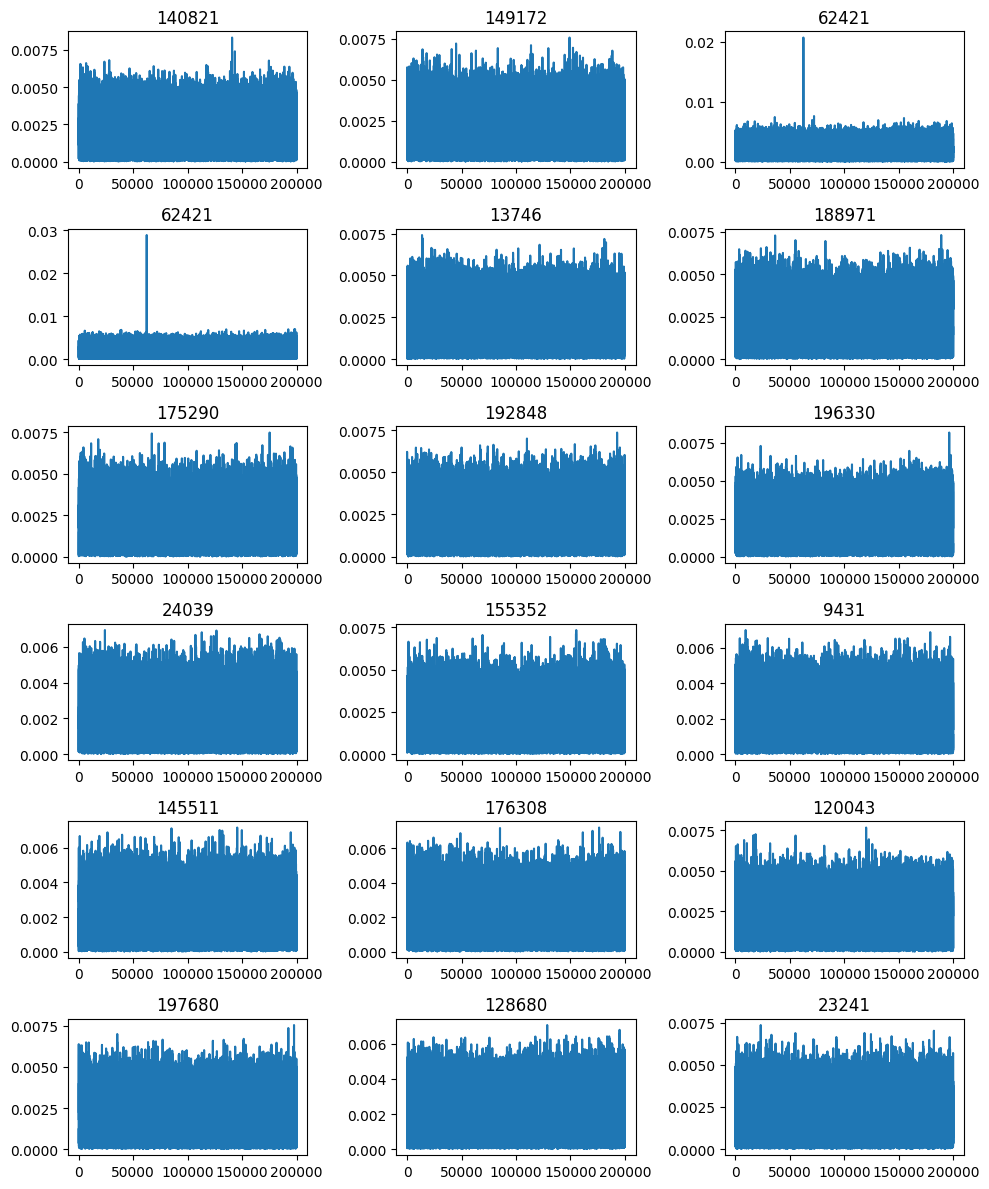

In [28]:
#UNCORRECTED
center = c_acclen
dN= 100000
fig,ax=plt.subplots(6,3)
fig.set_size_inches(10,12)
ax=ax.flatten()
for cc in range(18):
    mm=np.argmax(np.abs(xc_uncorr[cc,center-dN:center+dN]))
    ax[cc].set_title(f"{mm}")
    ax[cc].plot(np.abs(xc_uncorr[cc,center-dN:center+dN]))
plt.tight_layout()

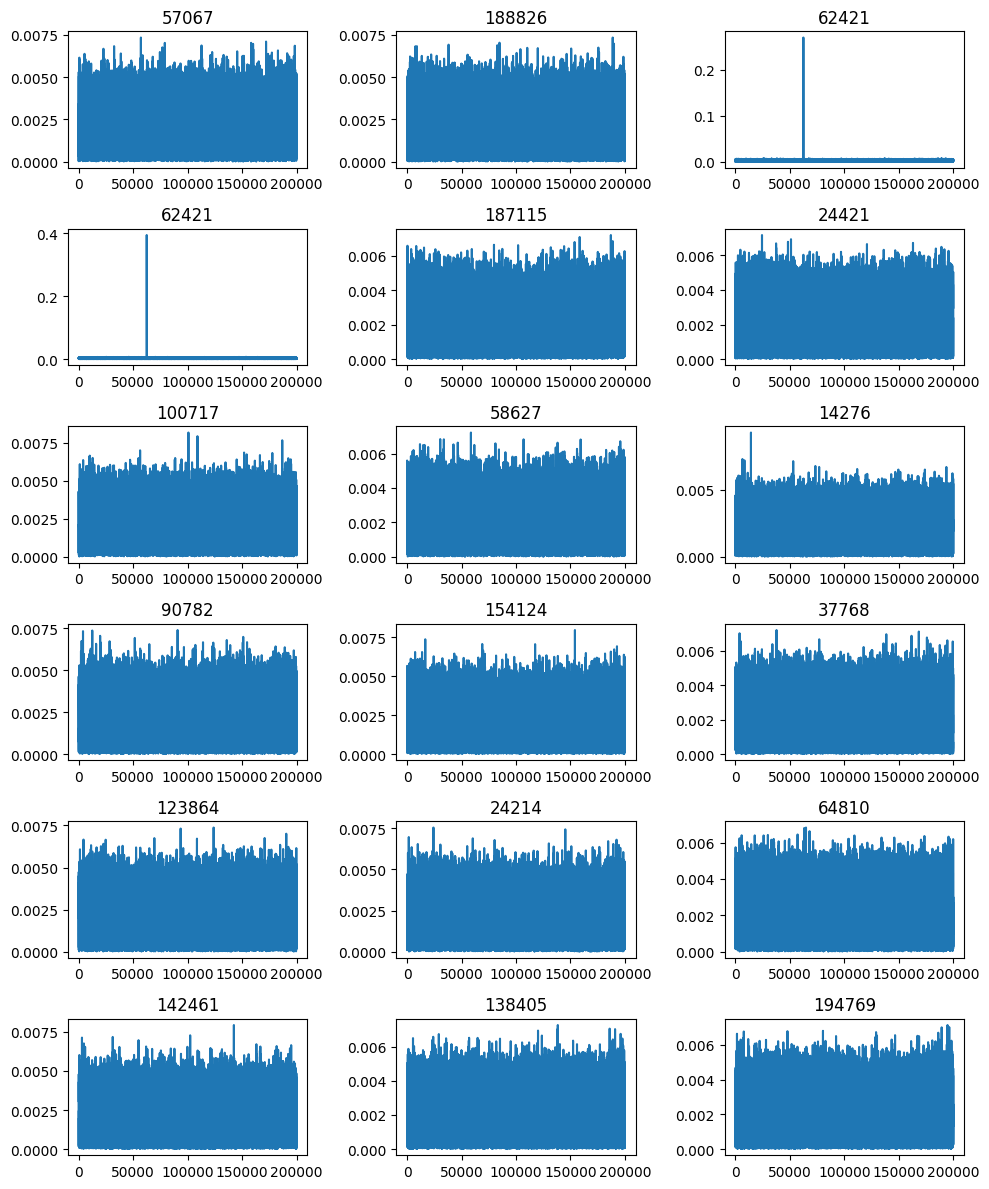

In [29]:
#CORRECTED
fig,ax=plt.subplots(6,3)
fig.set_size_inches(10,12)
ax=ax.flatten()
for cc in range(18):
    mm=np.argmax(np.abs(xc_corr[cc,center-dN:center+dN]))
    ax[cc].set_title(f"{mm}")
    #ax[cc].plot(np.abs(xc_uncorrected[cc, peak_center - 200:peak_center + 200]))
    ax[cc].plot(np.abs(xc_corr[cc,center-dN:center+dN]))
plt.tight_layout()

In [1]:
peak=np.argmax(np.abs(xc_corr[3,center-dN:center+dN]))
plt.plot(np.abs(xc_corr[3,center-dN:center+dN]))
plt.title(f"{peak}")
plt.tight_layout()

NameError: name 'np' is not defined

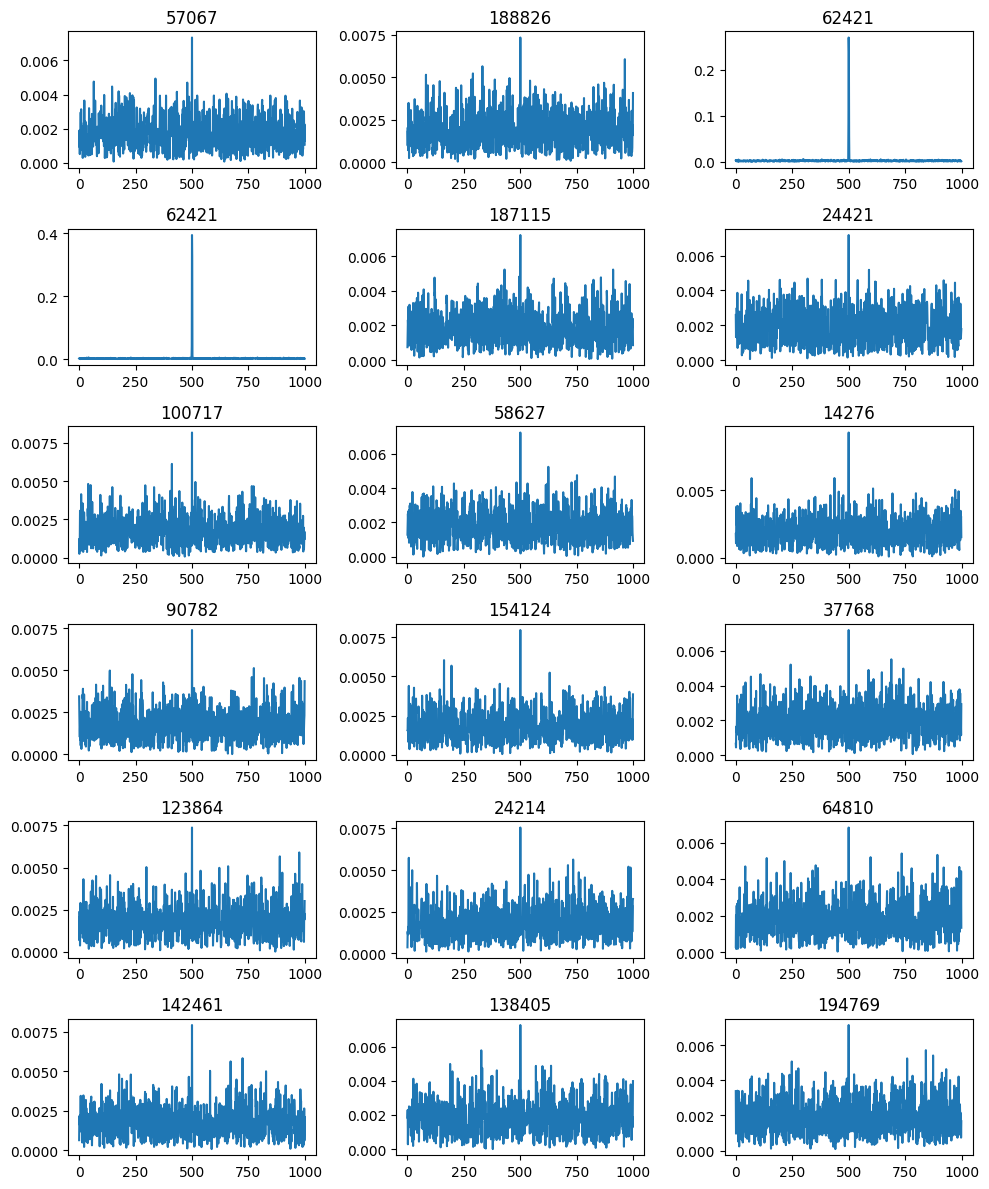

In [35]:
#Zoomed in!

dN= 100000
fig,ax=plt.subplots(6,3)
fig.set_size_inches(10,12)
ax=ax.flatten()
for cc in range(18):
    peak_data = np.abs(xc_corr[cc,c_acclen - dN:c_acclen + dN])
    peak_location = np.argmax(peak_data)
    ax[cc].set_title(f"{peak_location}")
    ax[cc].plot(peak_data[peak_location - 500:peak_location + 500])
plt.tight_layout()

0.12736009279438976
(array([200]), {'peak_heights': array([0.39448733])})


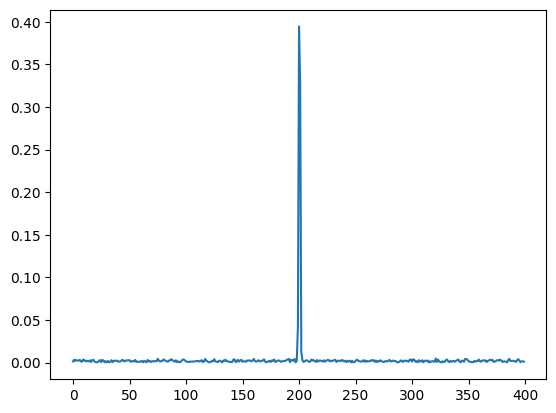

In [37]:
#need to clean this part up.


peak_center = c_acclen - (dN - 62421)

#get the data you want to look at
data = np.abs(xc_corr[3][peak_center-200: peak_center+200])
plt.plot(data)

#determine the minimum prominence we want
noise_level = np.std(data)
desired_snr = 5 
min_prominence = desired_snr * noise_level
print(min_prominence)

#get our peak information

# make relative !!!!!!!
peaks_total = sn.find_peaks(data, height=0.01)
peaks_loud = sn.find_peaks(data, prominence=min_prominence)

print(peaks_total)


In [18]:
peak_location = np.argmax(data)
peak_data = data[peak_location - 200:peak_location + 200]
peaks_total = sn.find_peaks(data, height=0.001)
heights = peaks_total[1]['peak_heights']
height_indices = np.argsort(heights)

tallest = heights[height_indices[-1]]
reps, total = 4, 0
for i in range(reps):
    total += (tallest - heights[height_indices[-(i+2)]])
rel_ratio = (total/(tallest * reps))
print("\nRELIABILITY RATIO:", rel_ratio)

if rel_ratio < 0.15:
    sat_label = "UNRELIABLE"
elif rel_ratio > 0.7:
    sat_label = "RELIABLE"
else:
    sat_label = "UNCLEAR"

print("\nSTATUS:", sat_label)


RELIABILITY RATIO: 0.024161693394190966

STATUS: UNRELIABLE


<h1 style="font-size:30pt">VISIBILITY</h1>

In [8]:
idx_correction=86568-100000
if idx_correction>0:
    idx1_v = idx1 + idx_correction
    idx2_v = idx2
else:
    idx2_v = idx2 + np.abs(idx_correction)
    idx1_v = idx1
print("Corrected Starting Indices:", idx1_v, idx2_v)

Corrected Starting Indices: 305176 2027592


In [9]:
ant1_v = bdc.BasebandFileIterator(files_a1, 0, idx1_v, v_acclen, nchunks=v_nchunks, chanstart=chanstart, chanend=chanend, type='float')
ant2_v = bdc.BasebandFileIterator(files_a2, 0, idx2_v, v_acclen, nchunks=v_nchunks, chanstart=chanstart, chanend=chanend, type='float')

ACCLEN RECEIVED IS 30000
took 0.266 seconds to read raw data on  /scratch/s/sievers/mohanagr/mars1_2024/baseband/17218/1721800712.raw
START SPECNUM IS 1033442694 obj start at 1033137518
ACCLEN RECEIVED IS 30000
took 0.173 seconds to read raw data on  /scratch/s/sievers/mohanagr/mars2_2024/baseband/17218/1721800684.raw
START SPECNUM IS 1089686353 obj start at 1087658761


In [10]:
m1=ant1_v.spec_num_start
m2=ant2_v.spec_num_start
visibility_phased = np.zeros((v_nchunks,len(ant1_v.channel_idxs)), dtype='complex64')
st=time.time()
        
for i, (chunk1,chunk2) in enumerate(zip(ant1_v,ant2_v)):
        # pol00[i,:] = cr.avg_xcorr_4bit_2ant(chunk1['pol0'], chunk2['pol0'],chnk1['specnums'],chunk2['specnums'],m1+i*acclen,m2+i*acclen)
        xcorr = avg_xcorr_4bit_2ant_float(
                chunk1['pol0'], 
                chunk2['pol0'],
                chunk1['specnums'],
                chunk2['specnums'],
                m1+i*v_acclen,
                m2+i*v_acclen)
        visibility_phased[i,:] = np.sum(xcorr,axis=0)/v_acclen
        print("CHUNK", i, " has ", xcorr.shape[0], " rows")
print("Time taken final:", time.time()-st)
visibility_phased = np.ma.masked_invalid(visibility_phased)

CHUNK 0  has  30000  rows
CHUNK 1  has  30000  rows
CHUNK 2  has  30000  rows
CHUNK 3  has  30000  rows
CHUNK 4  has  30000  rows
CHUNK 5  has  30000  rows
CHUNK 6  has  30000  rows
CHUNK 7  has  30000  rows
CHUNK 8  has  30000  rows
CHUNK 9  has  30000  rows
CHUNK 10  has  30000  rows
CHUNK 11  has  30000  rows
CHUNK 12  has  30000  rows
CHUNK 13  has  30000  rows
CHUNK 14  has  30000  rows
CHUNK 15  has  30000  rows
CHUNK 16  has  30000  rows
CHUNK 17  has  30000  rows
CHUNK 18  has  30000  rows
CHUNK 19  has  30000  rows
CHUNK 20  has  30000  rows
CHUNK 21  has  30000  rows
took 1.306 seconds to read raw data on  /scratch/s/sievers/mohanagr/mars2_2024/baseband/17218/1721800729.raw
CHUNK 22  has  30000  rows
CHUNK 23  has  30000  rows
CHUNK 24  has  30000  rows
CHUNK 25  has  30000  rows
CHUNK 26  has  30000  rows
CHUNK 27  has  30000  rows
CHUNK 28  has  30000  rows
CHUNK 29  has  30000  rows
CHUNK 30  has  30000  rows
CHUNK 31  has  30000  rows
CHUNK 32  has  30000  rows
CHUNK 33  

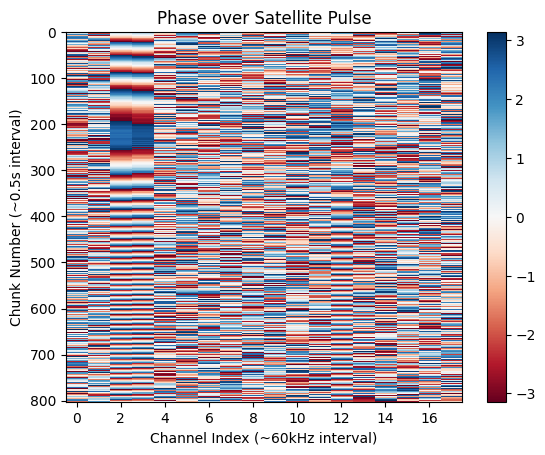

In [12]:
isolated_time = 803
vis_phase = np.angle(visibility_phased)

# vis_phase_1clk = np.angle(visibility_1clk)
plt.xlabel("Channel Index (~60kHz interval)")
plt.ylabel("Chunk Number (~0.5s interval)")
plt.title("Phase over Satellite Pulse")
plt.imshow(vis_phase[:isolated_time,:], aspect='auto',cmap='RdBu',interpolation="none")

plt.colorbar()

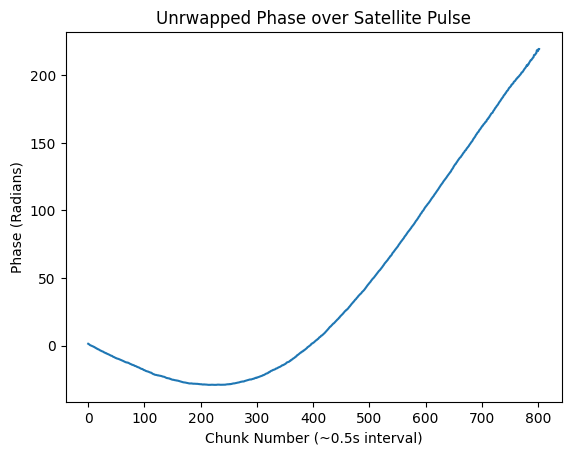

In [17]:
plt.xlabel("Chunk Number (~0.5s interval)")
plt.ylabel("Phase (Radians)")
plt.title("Unrwapped Phase over Satellite Pulse")
plt.plot(np.unwrap(vis_phase[0:isolated_time,2]))